In [1]:
import hashlib, math, random, re, time, zlib
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Set, Tuple
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

SEED = 0
import warnings
warnings.filterwarnings("ignore")
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

print(f"Using device: {device}")

# documents pulled from the C4 stream
N_DOCS = 3000  
# Wikipedia paragraphs for the reference language model
N_WIKI = 20_000  

device: mps


# 1) Raw Corpus

- A frontier model sees 10-30 trillion tokens, and almost all of them start as CommonCrawl.
- Almost all of the value comes from what you *throw away*: FineWeb kept roughly 8% of the raw crawl
- DataComp-LM found that the gap between their best and worst filtering pipeline was
larger than the gap from doubling model size. 

Two properties matter downstream and are worth measuring before we filter anything:
- **The length distribution is extremely heavy-tailed.** Most documents are tiny fragments;
  a small number carry most of the tokens. Any filter that operates per-document therefore
  removes a much larger fraction of *documents* than of *tokens*, and the token number is the
  one that matters for a training budget.

- **Boilerplate dominates short documents.** The nav menu, footer and sidebar are repeated on
  every page of a site, so a large share of the extracted text is navigation rather than
  content. Note that this repetition is mostly *within* documents at this sample size --
  cross-document near-duplication only becomes visible at crawl scale, as stage 3 will show.

In [2]:
# ── stream the raw crawl ──────────────────────────────────────────────────
t0 = time.time()
stream = load_dataset("allenai/c4", "en.noclean", split="train", streaming=True)

RAW_CORPUS: List[Dict] = []
for i, rec in enumerate(stream):
    RAW_CORPUS.append({"id": f"c4-{i:05d}", "text": rec["text"], "url": rec.get("url", "")})
    if len(RAW_CORPUS) >= N_DOCS:
        break

word_counts = np.array([len(d["text"].split()) for d in RAW_CORPUS])
print(f"loaded {len(RAW_CORPUS)} documents in {time.time()-t0:.1f}s")
print(f"words per doc: median={np.median(word_counts):.0f}  mean={word_counts.mean():.0f}  "
      f"p99={np.percentile(word_counts, 99):.0f}  max={word_counts.max()}")

# the heavy tail: what share of tokens lives in the longest 10% of documents?
srt = np.sort(word_counts)[::-1]
top10 = srt[: len(srt) // 10].sum() / srt.sum()
print(f"longest 10% of documents hold {top10:.0%} of all words")

print("\n--- a typical raw document -------------------------------------")
print(RAW_CORPUS[1]["text"][:600])

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7168 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

loaded 3000 documents in 15.2s
words per doc: median=537  mean=992  p99=8800  max=24650
longest 10% of documents hold 46% of all words

--- a typical raw document -------------------------------------
Beginners BBQ Class Taking Place in Missoula!
Need to Know
Poem Home
Local News
Around the Web
Get the KLYQ App
We're Alexa-Enabled
Montana Pass Cameras
Bitterroot Outdoor Journal
Hamilton Broncs
Air Quality
Sign In
Home
On Air
Our Shows
Steve Fullerton
Listen
Listen Live
Mobile App
VIP
Sign Up
Contest Rules
Newsletter
Win Stuff
Weather
Local Experts
Contact
Help
Advertise
Townsquare Interactive
Employment
More
Home
On Air
Our Shows
Steve Fullerton
Listen
Listen Live
Mobile App
VIP
Sign Up
Contest Rules
Newsletter
Win Stuff
Weather
Local Experts
Contact
Help
Advertise
Townsquare Interactive
Em


# 2) Heuristic Filters

Each rule targets a specific failure mode of text extraction:

| Filter | Rejects | Because |
|---|---|---|
| `length` | < 50 words | fragments, error pages, pure nav menus |
| `symbol_ratio` | > 10% non-alphanumeric | code dumps, ASCII art, garbled encodings |
| `word_length` | mean outside [3, 15] chars | numeric lists (short), base64/hashes (long) |
| `repetition` | top 5-gram covers > 30% | SEO spam, "click here click here click here" |
| `unique_words` | < 20% unique tokens | auto-generated and templated text |
| `stop_word` | < 2 common English words | non-English, keyword lists, tag clouds |
| `ellipsis_lines` | > 30% of lines end in `...` | truncated listing / index pages |

The whole cascade **short-circuits** on the first failure. With the cheapest rules ordered
first, the average document costs far less than running all seven.

In [3]:
@dataclass
class FilterConfig:
    min_words: int = 50
    max_words: int = 100_000
    max_symbol_ratio: float = 0.10
    min_mean_word_len: float = 3.0
    max_mean_word_len: float = 15.0
    max_dup_ngram_frac: float = 0.30  # Gopher top n-gram duplication fraction
    ngram_size: int = 5
    min_unique_word_ratio: float = 0.20
    min_stop_words: int = 2
    max_ellipsis_line_frac: float = 0.30


CFG = FilterConfig()

# Gopher's stop-word list: any real English document contains several of these
STOP_WORDS = {"the", "be", "to", "of", "and", "that", "have", "with"}


def filter_length(text: str, cfg: FilterConfig) -> bool:
    """Accept if word count is within [min_words, max_words]."""
    return cfg.min_words <= len(text.split()) <= cfg.max_words


def filter_symbol_ratio(text: str, cfg: FilterConfig) -> bool:
    """Reject when non-alphanumeric characters exceed the threshold."""
    if not text:
        return False
    non_alpha = sum(1 for c in text if not c.isalnum() and not c.isspace())
    return non_alpha / len(text) <= cfg.max_symbol_ratio


def filter_word_length(text: str, cfg: FilterConfig) -> bool:
    """Reject if mean word length falls outside a plausible range.

    Short mean -> numeric lists or single characters; long mean -> hashes, base64.
    """
    words = text.split()
    if not words:
        return False
    mean_len = sum(len(w) for w in words) / len(words)
    return cfg.min_mean_word_len <= mean_len <= cfg.max_mean_word_len


def filter_stop_words(text: str, cfg: FilterConfig) -> bool:
    """Gopher's cheap language check: English prose cannot avoid common function words."""
    words = set(text.lower().split())
    return len(words & STOP_WORDS) >= cfg.min_stop_words


def filter_ellipsis_lines(text: str, cfg: FilterConfig) -> bool:
    """Reject listing pages, where most lines are truncated previews ending in '...'."""
    lines = [l for l in text.split("\n") if l.strip()]
    if not lines:
        return False
    ellipsis = sum(1 for l in lines if l.rstrip().endswith(("...", "…")))
    return ellipsis / len(lines) <= cfg.max_ellipsis_line_frac


def filter_repetition(text: str, cfg: FilterConfig) -> bool:
    """Gopher top-n-gram duplication fraction.

    fraction = (occurrences of the single most frequent n-gram * n) / total tokens
    """
    words = text.lower().split()
    n, total = cfg.ngram_size, len(words)

    # too short to judge; the length filter already handled it
    if total < n:
        return True  
    
    ngrams = [tuple(words[i : i + n]) for i in range(total - n + 1)]
    most_common = Counter(ngrams).most_common(1)[0][1]
    return (most_common * n) / total <= cfg.max_dup_ngram_frac


def filter_unique_words(text: str, cfg: FilterConfig) -> bool:
    """Reject documents with very low lexical diversity."""
    words = text.lower().split()
    if not words:
        return False
    return len(set(words)) / len(words) >= cfg.min_unique_word_ratio


# ordered cheapest-first so the short-circuit saves the most work
FILTERS = [
    ("length", filter_length),
    ("symbol_ratio", filter_symbol_ratio),
    ("word_length", filter_word_length),
    ("stop_word", filter_stop_words),
    ("ellipsis_lines", filter_ellipsis_lines),
    ("unique_words", filter_unique_words),
    ("repetition", filter_repetition),  # most expensive: builds every n-gram
]


def apply_heuristic_filters(doc: Dict, cfg: FilterConfig) -> Tuple[bool, Optional[str]]:
    """Run each filter in order; return (passed, name_of_first_failure)."""
    for name, fn in FILTERS:
        if not fn(doc["text"], cfg):
            return False, name
    return True, None


t0 = time.time()
rejection_counts: Counter = Counter()
heuristic_passed: List[Dict] = []
for doc in RAW_CORPUS:
    passed, reason = apply_heuristic_filters(doc, CFG)
    if passed:
        heuristic_passed.append(doc)
    else:
        rejection_counts[reason] += 1
elapsed = time.time() - t0

kept_words = sum(len(d["text"].split()) for d in heuristic_passed)
print(f"documents : {len(RAW_CORPUS)} -> {len(heuristic_passed)} "
      f"({len(heuristic_passed)/len(RAW_CORPUS):.1%} kept)")
print(f"words     : {word_counts.sum()} -> {kept_words} ({kept_words/word_counts.sum():.1%} kept)")
print(f"throughput: {len(RAW_CORPUS)/elapsed:,.0f} docs/sec on one core\n")
for name, _ in FILTERS:
    print(f"  rejected by {name:16s}: {rejection_counts[name]:5d}")

documents : 3000 -> 2588 (86.3% kept)
words     : 2974851 -> 2394770 (80.5% kept)
throughput: 3,041 docs/sec on one core

  rejected by length          :   126
  rejected by symbol_ratio    :   111
  rejected by word_length     :    10
  rejected by stop_word       :   107
  rejected by ellipsis_lines  :     8
  rejected by unique_words    :    41
  rejected by repetition      :     9


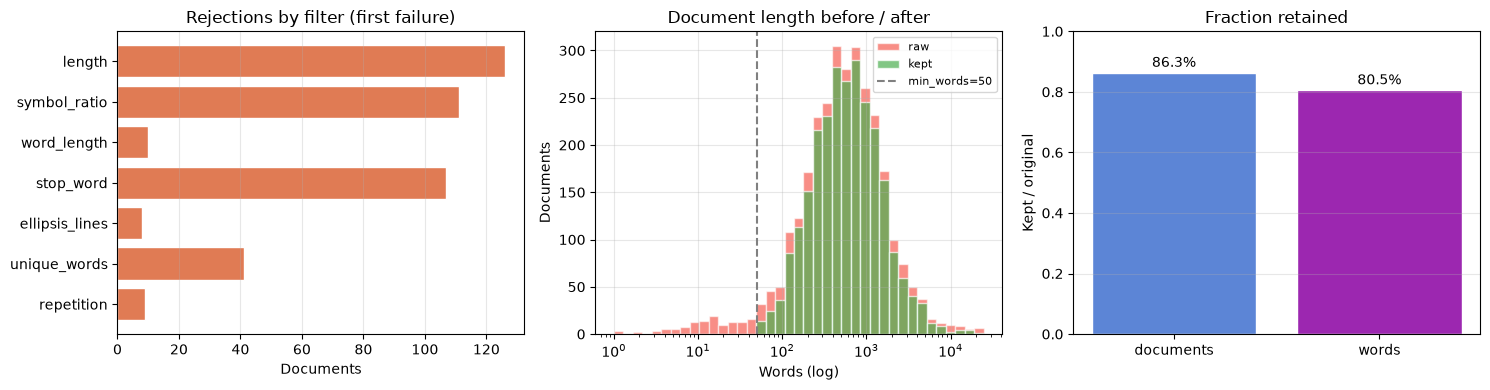

---A document the filters threw out ---------------------------
[rejected by unique_words]
Maryland Concert Tickets | Heart, Joan Jett and the Blackhearts & Elle King 8/13/2019
Maryland Concert Tickets
Menu:
Home
Buy Tickets
Ticket Brokers
Watch Video
Share on Facebook
Please note: Maryland Concert Tickets is not affiliated with any official Maryland Concert website or any Maryland Concert box office.
» More info
Heart, Joan Jett and the Blackhearts & Elle King Tickets
Merriweather Post


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

names = [n for n, _ in FILTERS]
axes[0].barh(names[::-1], [rejection_counts[n] for n in names][::-1],
             color="#e07b54", edgecolor="white")
axes[0].set_title("Rejections by filter (first failure)")
axes[0].set_xlabel("Documents")
axes[0].grid(axis="x", alpha=0.3)

kept_wc = np.array([len(d["text"].split()) for d in heuristic_passed])
bins = np.logspace(0, np.log10(max(word_counts.max(), 2)), 40)
axes[1].hist(word_counts, bins=bins, alpha=0.6, color="#F44336", label="raw", edgecolor="white")
axes[1].hist(kept_wc, bins=bins, alpha=0.7, color="#4CAF50", label="kept", edgecolor="white")
axes[1].axvline(CFG.min_words, color="gray", ls="--", label=f"min_words={CFG.min_words}")
axes[1].set_xscale("log")
axes[1].set_title("Document length before / after")
axes[1].set_xlabel("Words (log)")
axes[1].set_ylabel("Documents")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# documents vs tokens: the filters are far harsher on documents than on tokens
axes[2].bar(["documents", "words"],
            [len(heuristic_passed) / len(RAW_CORPUS), kept_words / word_counts.sum()],
            color=["#5c85d6", "#9C27B0"], edgecolor="white")
axes[2].set_ylim(0, 1)
axes[2].set_title("Fraction retained")
axes[2].set_ylabel("Kept / original")
for i, v in enumerate([len(heuristic_passed) / len(RAW_CORPUS), kept_words / word_counts.sum()]):
    axes[2].text(i, v + 0.02, f"{v:.1%}", ha="center")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("---A document the filters threw out ---------------------------")
for doc in RAW_CORPUS:
    ok, why = apply_heuristic_filters(doc, CFG)
    if not ok and why in ("repetition", "unique_words", "ellipsis_lines"):
        print(f"[rejected by {why}]\n{doc['text'][:400]}")
        break

# 3) Deduplication

Lee et al. (2022) showed that deduplicating training data lets a model reach the same loss
with less compute, and sharply reduces verbatim memorisation of training text. 

There are three levels:

| Method | Complexity | Catches |
|---|---|---|
| SHA-256 hash set | O(n) | byte-identical documents |
| MinHash + LSH | O(n) | Jaccard similarity above a threshold |
| Union-Find | O(n a(n)) | whole *clusters* of near-duplicates |

The third step is the one people forget. Near-duplication is not a pairwise relation you can
resolve pairwise: if A~B and B~C but A/~C, dropping the pair (A,B) still leaves you with two
copies. Web mirrors arrive in clusters, so you have to find connected components and keep one
representative from each.

**Set expectations before running it:** on a few thousand documents sampled from across the
crawl you should expect to find almost nothing. Duplicate pages are far apart in the crawl,
and the sample is too sparse to contain both halves of a pair. Lee et al. found ~3% exact
duplicates in C4 and far more in raw CommonCrawl -- but they looked at the whole corpus. What
this section demonstrates is that the algorithm is correct and what it costs; the payoff is a
scale effect you cannot see in a notebook. That is worth knowing explicitly, because a small
test that finds no duplicates is easy to misread as a broken implementation.

**Why MinHash works.** For a random hash function `h`, the probability that two sets share
their minimum hashed element is exactly their Jaccard similarity:

    P[min h(A) = min h(B)] = |A n B| / |A u B| = J(A, B)

So comparing 128 independent minima estimates `J` to within about `1/sqrt(128)` ~ 9%, using
128 integers per document instead of the document itself.

**Why banding works.** Split the 128 hashes into `b` bands of `r` rows and bucket documents by
each band. Two documents collide in a given band with probability `J^r`, so they become
candidates with probability `1 - (1 - J^r)^b` -- an S-curve with its knee near
`(1/b)^(1/r)`. Tuning `b` and `r` moves the knee to the similarity you actually care about,
and turns an O(n^2) all-pairs comparison into a hash-table lookup.

In [5]:
def normalise_text(text: str) -> str:
    """Canonical form for hashing: lower-cased, whitespace collapsed."""
    return " ".join(text.lower().split())

def exact_dedup(docs: List[Dict]) -> List[Dict]:
    """Remove documents that are identical after normalisation. O(n) via a hash set."""
    seen: Set[str] = set()
    unique: List[Dict] = []
    for doc in docs:
        digest = hashlib.sha256(normalise_text(doc["text"]).encode()).hexdigest()
        if digest not in seen:
            seen.add(digest)
            unique.append(doc)
    return unique

exact_deduped = exact_dedup(heuristic_passed)
print(f"exact dedup: {len(heuristic_passed)} -> {len(exact_deduped)} "
      f"(removed {len(heuristic_passed) - len(exact_deduped)})")

exact dedup: 2588 -> 2587 (removed 1)


In [6]:
# MinHash signatures
# hash universe, large enough to avoid collisions
MERSENNE_PRIME = (1 << 61) - 1  

@dataclass
class LSHConfig:
    num_hashes: int = 128
    num_bands: int = 16
    shingle_size: int = 5  # word n-gram size
    threshold: float = 0.70

    @property
    def rows_per_band(self) -> int:
        assert self.num_hashes % self.num_bands == 0
        return self.num_hashes // self.num_bands


def generate_hash_params(num_hashes: int, prime: int, seed: int = SEED):
    """Sample (a, b) for the universal hash family h(x) = (a*x + b) mod p.

    Seeded, so a rerun of the notebook reproduces the same clusters.
    """
    rng = np.random.default_rng(seed)
    return rng.integers(1, prime, size=num_hashes), rng.integers(0, prime, size=num_hashes)


def get_shingles(text: str, k: int) -> Set[int]:
    """Word k-grams mapped to integer ids.

    crc32 rather than the builtin hash(): Python randomises string hashing per
    process, which would make deduplication non-reproducible across runs.
    """
    words = normalise_text(text).split()
    return {
        zlib.crc32(" ".join(words[i : i + k]).encode()) for i in range(len(words) - k + 1)
    }


def compute_minhash_signature(shingles: Set[int], a, b, prime: int) -> np.ndarray:
    """Minimum of each hash function over the document's shingles -> (num_hashes,)."""
    arr = np.fromiter(shingles, dtype=np.int64, count=len(shingles))  # (num_shingles,)
    # (num_hashes, 1) * (num_shingles,) -> (num_hashes, num_shingles), then min over shingles
    return ((a[:, None] * arr[None, :] + b[:, None]) % prime).min(axis=1)


def build_minhash_signatures(docs: List[Dict], cfg: LSHConfig):
    """Return (sig_matrix (num_kept, num_hashes), kept_docs) -- kept in lockstep.

    Documents too short to produce a shingle are carried through unchanged rather
    than silently dropped, so signature rows always align with kept_docs.
    """
    a, b = generate_hash_params(cfg.num_hashes, MERSENNE_PRIME)
    signatures, kept, no_shingles = [], [], []
    for doc in docs:
        shingles = get_shingles(doc["text"], cfg.shingle_size)
        if not shingles:
            no_shingles.append(doc)
            continue
        signatures.append(compute_minhash_signature(shingles, a, b, MERSENNE_PRIME))
        kept.append(doc)
    return np.stack(signatures, axis=0), kept, no_shingles


LSH_CFG = LSHConfig()
t0 = time.time()
sig_matrix, sig_docs, unshingled = build_minhash_signatures(exact_deduped, LSH_CFG)
print(f"signature matrix: {sig_matrix.shape}  (documents x hashes)  in {time.time()-t0:.1f}s")
print(f"{sig_matrix.nbytes/1e3:.0f} KB of signatures stands in for "
      f"{sum(len(d['text']) for d in sig_docs)/1e6:.1f} MB of text")

signature matrix: (2587, 128)  (documents x hashes)  in 1.1s
2649 KB of signatures stands in for 15.2 MB of text


In [7]:
# LSH banding
def lsh_band_buckets(sig_matrix: np.ndarray, cfg: LSHConfig) -> Dict[Tuple, List[int]]:
    """Bucket documents by each band of their signature.

    Sharing a bucket in any single band makes two documents candidates.
    """
    r = cfg.rows_per_band
    buckets: Dict[Tuple, List[int]] = defaultdict(list)
    for band in range(cfg.num_bands):
        band_slice = sig_matrix[:, band * r : (band + 1) * r]  # (num_docs, r)
        for doc_idx in range(sig_matrix.shape[0]):
            buckets[(band, tuple(band_slice[doc_idx].tolist()))].append(doc_idx)
    return buckets


def find_candidate_pairs(buckets: Dict[Tuple, List[int]]) -> Set[Tuple[int, int]]:
    """Every pair sharing at least one bucket. Huge buckets are the boilerplate clusters."""
    candidates: Set[Tuple[int, int]] = set()
    for indices in buckets.values():
        if len(indices) < 2:
            continue
        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                candidates.add((indices[i], indices[j]))
    return candidates


t0 = time.time()
buckets = lsh_band_buckets(sig_matrix, LSH_CFG)
candidate_pairs = find_candidate_pairs(buckets)
n_pairs_all = len(sig_docs) * (len(sig_docs) - 1) // 2
print(f"candidate pairs : {len(candidate_pairs):,} in {time.time()-t0:.1f}s")
print(f"all-pairs would be {n_pairs_all:,} comparisons "
      f"-- LSH looks at {len(candidate_pairs)/max(n_pairs_all,1):.2%} of them")

candidate pairs : 2 in 0.0s
all-pairs would be 3,344,991 comparisons -- LSH looks at 0.00% of them


In [8]:
# Union-Find clustering
class UnionFind:
    """Disjoint sets with path compression and union by rank.

    Turns pairwise near-duplicate relations into connected components, so an
    entire mirror cluster collapses to one representative.
    """

    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x: int) -> int:
        while self.parent[x] != x:  # iterative: web clusters can be deep
            self.parent[x] = self.parent[self.parent[x]]  # path halving
            x = self.parent[x]
        return x

    def union(self, x: int, y: int) -> None:
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1


def jaccard_from_signatures(sig_a: np.ndarray, sig_b: np.ndarray) -> float:
    """Estimate J as the fraction of hash functions where the two minima agree."""
    return float(np.mean(sig_a == sig_b))


def fuzzy_dedup(sig_matrix, docs: List[Dict], candidate_pairs, cfg: LSHConfig):
    """Verify candidates, cluster them, and keep one document per cluster."""
    uf = UnionFind(len(docs))
    confirmed = 0
    for i, j in candidate_pairs:
        if jaccard_from_signatures(sig_matrix[i], sig_matrix[j]) >= cfg.threshold:
            uf.union(i, j)
            confirmed += 1

    clusters: Dict[int, List[int]] = defaultdict(list)
    for i in range(len(docs)):
        clusters[uf.find(i)].append(i)

    kept = [docs[members[0]] for members in clusters.values()]
    sizes = sorted((len(m) for m in clusters.values()), reverse=True)
    return kept, clusters, confirmed, sizes


t0 = time.time()
deduped, clusters, confirmed, cluster_sizes = fuzzy_dedup(
    sig_matrix, sig_docs, candidate_pairs, LSH_CFG
)
deduped = deduped + unshingled  # documents too short to shingle pass through
print(f"candidates confirmed above J>={LSH_CFG.threshold}: {confirmed:,} pairs "
      f"({confirmed/max(len(candidate_pairs),1):.1%} of candidates) in {time.time()-t0:.1f}s")
print(f"clusters: {len(clusters):,}   largest: {cluster_sizes[:8]}")
print(f"fuzzy dedup: {len(exact_deduped)} -> {len(deduped)} "
      f"(removed {len(exact_deduped) - len(deduped)})")

biggest = max(clusters.values(), key=len)
if len(biggest) > 1:
    print("\n--- two members of the largest near-duplicate cluster -----------")
    for idx in biggest[:2]:
        print(f"[{sig_docs[idx]['id']}] {' '.join(sig_docs[idx]['text'].split())[:220]}\n")

candidates confirmed above J>=0.7: 1 pairs (50.0% of candidates) in 0.0s
clusters: 2,586   largest: [2, 1, 1, 1, 1, 1, 1, 1]
fuzzy dedup: 2587 -> 2586 (removed 1)

--- two members of the largest near-duplicate cluster -----------
[c4-00224] Manuel F Diaz MD - Find a Doctor | Gainesville Internal Medicine Physicians Skip to main content Call Gainesville Internal Medicine Physicians at (352) 333-5242 Directions Search × Submit Search Recent Searches Call Gain

[c4-02508] Manuel F Diaz MD - Find a Doctor | Gainesville Internal Medicine Physicians Skip to main content Call Gainesville Internal Medicine Physicians at (352) 333-5242 Directions Search × Submit Search Recent Searches Call Gain



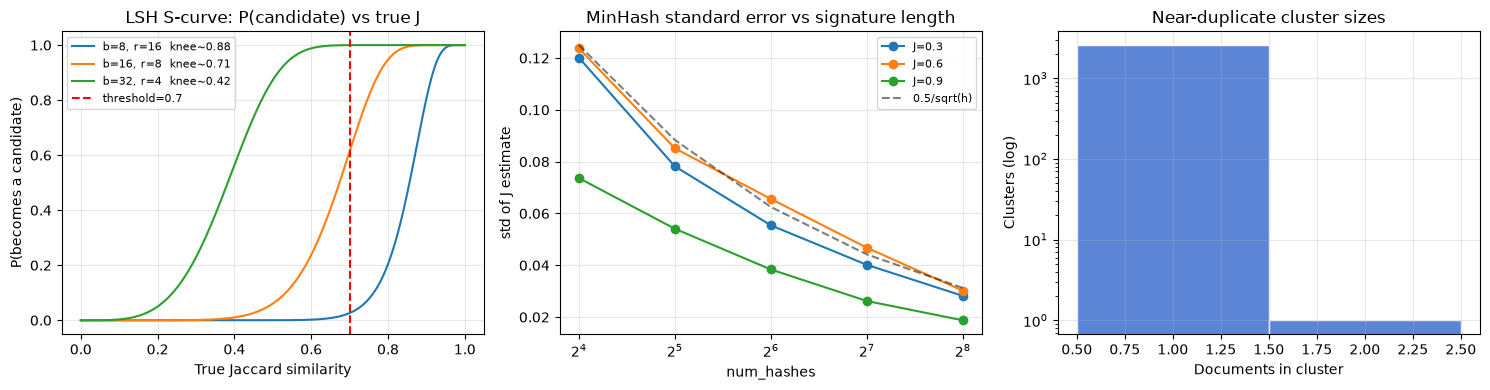

singleton clusters: 2,585 of 2,586  -- the remainder are the mirrored / templated pages


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. the band/row trade-off
J = np.linspace(0, 1, 300)
for b, r in [(8, 16), (16, 8), (32, 4)]:
    axes[0].plot(J, 1 - (1 - J**r) ** b, label=f"b={b}, r={r}  knee~{(1/b)**(1/r):.2f}")
axes[0].axvline(LSH_CFG.threshold, color="red", ls="--", label=f"threshold={LSH_CFG.threshold}")
axes[0].set_title("LSH S-curve: P(candidate) vs true J")
axes[0].set_xlabel("True Jaccard similarity")
axes[0].set_ylabel("P(becomes a candidate)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. MinHash estimation error shrinks as 1/sqrt(num_hashes)
rng = np.random.default_rng(SEED)
for true_j in [0.3, 0.6, 0.9]:
    hs = np.array([16, 32, 64, 128, 256])
    err = [rng.binomial(h, true_j, size=400).std() / h for h in hs]
    axes[1].plot(hs, err, "o-", label=f"J={true_j}")
axes[1].plot(hs, 0.5 / np.sqrt(hs), "k--", alpha=0.5, label="0.5/sqrt(h)")
axes[1].set_xscale("log", base=2)
axes[1].set_title("MinHash standard error vs signature length")
axes[1].set_xlabel("num_hashes")
axes[1].set_ylabel("std of J estimate")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. observed cluster sizes: duplication arrives in clumps
sizes = np.array(cluster_sizes)
axes[2].hist(sizes, bins=np.arange(1, min(sizes.max(), 30) + 2) - 0.5,
             color="#5c85d6", edgecolor="white", log=True)
axes[2].set_title("Near-duplicate cluster sizes")
axes[2].set_xlabel("Documents in cluster")
axes[2].set_ylabel("Clusters (log)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"singleton clusters: {(sizes == 1).sum():,} of {len(sizes):,}  "
      f"-- the remainder are the mirrored / templated pages")

# 4) Quality Filtering

Quality filtering is the first stage that needs an opinion about whether text is any good. 

Two families, and the history matters because they answer different questions.

## 4.1 CCNet Perplexity filtering

- Train a language model on a clean reference corpus, then score every document by how surprised that model is. 
- CCNet used **KenLM, a 5-gram count-based model with Kneser-Ney smoothing**, trained per-language on Wikipedia, NOT a neural network. 
- The rule is a **band-pass**, and both edges matter:
  - **Low perplexity**: the reference model finds the text totally predictable. On the web that
    means boilerplate, templated pages, keyword spam. Nothing to learn, and heavily duplicated.
  - **High perplexity**: the model has no idea what comes next: another language, OCR garbage,
    base64, minified JavaScript.

In [10]:
class NGramLanguageModel:
    """Count-based n-gram LM with stupid backoff (Brants et al., 2007).

    Add-k smoothing is the textbook choice and it fails badly here: with a 77k
    Wikipedia vocabulary, essentially every trigram in a web document is unseen,
    so every document pins to the same k*V ceiling and the model cannot rank
    anything. Backoff fixes that by falling back to the bigram, then the
    unigram, discounting by `alpha` at each step. This is why real n-gram LMs
    (KenLM, which CCNet used) always use a backoff or interpolated smoother.
    """

    BOS, EOS = "<BOS>", "<EOS>"

    def __init__(self, n: int = 3, alpha: float = 0.4):
        self.n, self.alpha = n, alpha
        # counts[k] = k-gram counts
        self.counts = [Counter() for _ in range(n + 1)]  
        self.total = 0
        self.vocab_size = 0

    def _pad(self, tokens: List[str]) -> List[str]:
        return [self.BOS] * (self.n - 1) + tokens + [self.EOS]

    def fit(self, texts: List[str]) -> "NGramLanguageModel":
        """Count every k-gram for k = 1..n; backoff needs all the orders."""
        for text in texts:
            tokens = self._pad(text.lower().split())
            self.total += len(tokens)
            for k in range(1, self.n + 1):
                counter = self.counts[k]
                for i in range(len(tokens) - k + 1):
                    counter[tuple(tokens[i : i + k])] += 1
        self.vocab_size = len(self.counts[1])
        return self

    def log_prob(self, ngram: Tuple[str, ...]) -> float:
        """Longest context that was actually observed, discounted by alpha^backoffs.

        Not a normalised probability -- that is what "stupid" refers to -- but it
        ranks documents correctly, which is all a filter needs.
        """
        for back in range(len(ngram)):
            sub = ngram[back:]
            if len(sub) == 1:
                break
            count = self.counts[len(sub)][sub]
            if count > 0:
                context = self.counts[len(sub) - 1][sub[:-1]]
                return math.log(self.alpha**back * count / context)
        # unigram floor, add-1 smoothed so an unknown word is finite
        unigram = self.counts[1][ngram[-1:]]
        return math.log(
            self.alpha ** (len(ngram) - 1) * (unigram + 1) / (self.total + self.vocab_size)
        )

    def perplexity(self, text: str) -> float:
        """exp of the mean negative log-likelihood per token.

        Reads as "the effective number of equally likely choices the model felt
        it had at each position".
        """
        tokens = self._pad(text.lower().split())
        if len(tokens) <= self.n - 1:
            return float("inf")
        total = sum(
            self.log_prob(tuple(tokens[i - self.n + 1 : i + 1]))
            for i in range(self.n - 1, len(tokens))
        )
        return math.exp(-total / (len(tokens) - self.n + 1))


t0 = time.time()
wiki_stream = load_dataset(
    "Salesforce/wikitext", "wikitext-103-raw-v1", split="train", streaming=True
)
wiki_paragraphs: List[str] = []
for rec in wiki_stream:
    para = rec["text"].strip()
    if len(para) > 200 and not para.startswith("="):  # skip section headings
        wiki_paragraphs.append(para)
    if len(wiki_paragraphs) >= N_WIKI:
        break

ngram_lm = NGramLanguageModel(n=3, alpha=0.4).fit(wiki_paragraphs)
print(f"reference LM fitted on {len(wiki_paragraphs):,} Wikipedia paragraphs "
      f"in {time.time()-t0:.1f}s")
print(f"vocabulary : {ngram_lm.vocab_size:,} types")
print(f"trigrams   : {len(ngram_lm.counts[3]):,} distinct")

reference LM fitted on 20,000 Wikipedia paragraphs in 8.6s
vocabulary : 77,265 types
trigrams   : 1,885,929 distinct


In [11]:
t0 = time.time()
for doc in deduped:
    doc["ngram_ppl"] = ngram_lm.perplexity(doc["text"])
elapsed = time.time() - t0

ppls = np.array([d["ngram_ppl"] for d in deduped])
print(f"scored {len(deduped)} documents in {elapsed:.1f}s "
      f"({len(deduped)/elapsed:,.0f} docs/sec -- this is why CCNet used n-grams)\n")
for q in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  p{q:<2d} perplexity: {np.percentile(ppls, q):>10,.0f}")

# CCNet bucketed documents into head / middle / tail by perplexity percentile
# rather than fixing absolute thresholds, since the scale depends on the LM.
PPL_LOW, PPL_HIGH = np.percentile(ppls, 5), np.percentile(ppls, 90)

def perplexity_filter(docs: List[Dict], lo: float, hi: float):
    """Band-pass on perplexity: reject the templated tail and the garbled tail."""
    passed = [d for d in docs if lo <= d["ngram_ppl"] <= hi]
    rejected = [d for d in docs if not (lo <= d["ngram_ppl"] <= hi)]
    return passed, rejected


ppl_passed, ppl_rejected = perplexity_filter(deduped, PPL_LOW, PPL_HIGH)
print(f"\nband [{PPL_LOW:,.0f}, {PPL_HIGH:,.0f}] keeps {len(ppl_passed)} of {len(deduped)}")

by_ppl = sorted(deduped, key=lambda d: d["ngram_ppl"])
print("\n--- LOWEST perplexity (expect templated / boilerplate) ----------")
print(" ".join(by_ppl[0]["text"].split())[:300])
print("\n--- HIGHEST perplexity (expect garbled / non-English) -----------")
print(" ".join(by_ppl[-1]["text"].split())[:300])

scored 2586 documents in 1.6s (1,617 docs/sec -- this is why CCNet used n-grams)

  p1  perplexity:      5,353
  p5  perplexity:      9,238
  p25 perplexity:     26,838
  p50 perplexity:     61,086
  p75 perplexity:    139,983
  p95 perplexity:    466,430
  p99 perplexity:  1,165,657

band [9,238, 305,780] keeps 2197 of 2586

--- LOWEST perplexity (expect templated / boilerplate) ----------
Home Builders in Wichita | Go Here For Houses | 316-201-6522 (316) 201-6522 Client Login Home Find Your Home Communities Floorplans Available Homes Gallery About Us Testimonials Contact Us Select Page Home Builders in Wichita | Go Here For Houses by ghageman_eu0e8o83 | May 1, 2018 | Home Builders in

--- HIGHEST perplexity (expect garbled / non-English) -----------
Mitsubishi M38B57E7-XXXFP M38860F3A-XXXFS M38037FD-FP M38031F21-FP M38076M3-XXXFS Start WithIncludedEndMatchDescription Path: okDatasheet > Semiconductor Datasheet > Mitsubishi Datasheet > Mitsubishi-79 0F3A-XXXFS M38037FD-FP M38031F21-FP

## 4.2 Small Neural Network

- Ankner et al. (2024), *"Perplexed by Perplexity"*, prune data with a 125M model and get measurable downstream gains for much larger models. 
- The n-gram score is dominated by *vocabulary overlap* with Wikipedia, an unseen token falls all the way to the unigram floor and takes a large backoff penalty, so a page full of product codes scores badly no matter how regular its structure. 
- GPT-2's score is dominated by *local predictability*, and it finds
boilerplate perfectly predictable because its training data was full of boilerplate. 

In [ ]:
import transformers
transformers.logging.set_verbosity_error() 

# GPT-2 (124M)
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")

# GPT-2 ships without a pad token
gpt2_tok.pad_token = gpt2_tok.eos_token  
gpt2 = AutoModelForCausalLM.from_pretrained("gpt2").to(device).eval()

@torch.no_grad()
def neural_perplexity(texts: List[str], batch_size: int = 8, max_length: int = 512):
    """Per-document perplexity under a causal LM.

    Padding is masked out of the mean so a short document in a long batch is not
    rewarded for its padding tokens.
    """
    # rank the sentence with the length
    # batch documents of similar length together
    order = sorted(range(len(texts)), key=lambda i: len(texts[i]))
    out = [0.0] * len(texts)
    for i in range(0, len(order), batch_size):
        idx = order[i : i + batch_size]
        enc = gpt2_tok(
            [texts[j] for j in idx], 
            return_tensors="pt", 
            padding=True,
            truncation=True, 
            max_length=max_length
        ).to(device)

        logits = gpt2(**enc).logits[:, :-1]          
        labels = enc["input_ids"][:, 1:]             
        mask = enc["attention_mask"][:, 1:].bool() 

        nll = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)).float(), 
            labels.reshape(-1),
            reduction="none",
        ).view(labels.shape)  
                                
        per_doc = torch.exp((nll * mask).sum(1) / mask.sum(1).clamp(min=1))
        for j, v in zip(idx, per_doc.cpu().tolist()):
            out[j] = v
            
    return out

In [20]:
# Sample
SAMPLE = deduped[:400]
t0 = time.time()
for doc, p in zip(SAMPLE, neural_perplexity([d["text"] for d in SAMPLE])):
    doc["gpt2_ppl"] = p

elapsed = time.time() - t0
print(f"GPT-2 scored {len(SAMPLE)} documents in {elapsed:.1f}s "
      f"({len(SAMPLE)/elapsed:.1f} docs/sec on {device})")

ng = np.array([d["ngram_ppl"] for d in SAMPLE])
nn = np.array([d["gpt2_ppl"] for d in SAMPLE])
rank_ng, rank_nn = ng.argsort().argsort(), nn.argsort().argsort()
spearman = np.corrcoef(rank_ng, rank_nn)[0, 1]
print(f"\nSpearman rank correlation between the two scorers: {spearman:+.3f}")
print("Essentially zero. Two filters both called 'perplexity filtering' rank the same")
print("corpus almost independently -- the name describes a recipe, not a criterion.")

worst = np.abs(rank_ng - rank_nn).argmax()
print(f"\nBiggest disagreement: Wikipedia-trigram rank {rank_ng[worst]}, "
      f"GPT-2 rank {rank_nn[worst]} (of {len(SAMPLE)})")
print(" ".join(SAMPLE[worst]["text"].split())[:320])

GPT-2 scored 400 documents in 85.3s (4.7 docs/sec on mps)

Spearman rank correlation between the two scorers: -0.023
Essentially zero. Two filters both called 'perplexity filtering' rank the same
corpus almost independently -- the name describes a recipe, not a criterion.

--- biggest disagreement: Wikipedia-trigram rank 395, GPT-2 rank 2 (of 400) ---
Sea Guap Photo, Sea Guap photos, Phillip Colla Natural History Photography :: Online Photo Search Sea Guap Photo Home > Natural History Photography Blog > Search > Sea Guap Sperm whale. Sea Guap Photo. Image ID: 02078 Species: Sperm whale, Physeter macrocephalus Location: Sao Miguel Island, Azores, Portugal Sperm whale


## 4.3 Classifier filtering

Perplexity asks "Is this the kind of text my reference corpus contained?" 

A classifier asks the question you actually care about: "Is this text *worth training on*?" 

The lineage:
- **LLaMA 1 (2023)**: fastText linear classifier, Wikipedia-referenced pages as positives against random CommonCrawl as negatives.
- **Phi / "Textbooks Are All You Need" (2023)**: GPT-4 labels documents for educational value, then a small classifier learns to imitate those labels.
- **FineWeb-Edu (2024)** -- Llama-3-70B scored 500k documents 0-5 for educational value, and that judgement was distilled into a **109M parameter regression head on a `Snowflake-arctic-embed-m` encoder**. Training on the filtered result beat unfiltered FineWeb by large margins on MMLU and ARC.
- **DCLM (2024)** -- Ran the controlled comparison and found plain fastText *beat* the more expensive options, including asking an LLM per document.

The pattern is the same every time: A large model (or a human) supplies judgement once, and it is compressed into something cheap enough to run billions of times. 

In [22]:
edu_tok = AutoTokenizer.from_pretrained("HuggingFaceFW/fineweb-edu-classifier")
edu_clf = (
    AutoModelForSequenceClassification.from_pretrained("HuggingFaceFW/fineweb-edu-classifier")
    .to(device)
    .eval()
)
print(
    f"{sum(p.numel() for p in edu_clf.parameters())/1e6:.0f}M parameters, "
    f"num_labels={edu_clf.config.num_labels} (regression: one 0-5 score)"
)

@torch.no_grad()
def educational_score(texts: List[str], batch_size: int = 16, max_length: int = 512):
    """Predicted educational value, 0 (useless) to 5 (textbook-grade)."""
    scores: List[float] = []
    for i in range(0, len(texts), batch_size):
        enc = edu_tok(
            texts[i : i + batch_size], 
            return_tensors="pt", 
            padding=True,
            truncation=True, 
            max_length=max_length
        ).to(device)
        scores.extend(edu_clf(**enc).logits.squeeze(-1).float().cpu().tolist())
    return scores

t0 = time.time()
for doc, s in zip(SAMPLE, educational_score([d["text"] for d in SAMPLE])):
    doc["edu_score"] = s
print(f"scored {len(SAMPLE)} documents in {time.time()-t0:.1f}s")
edu_scores = np.array([d["edu_score"] for d in SAMPLE])

by_edu = sorted(SAMPLE, key=lambda d: d["edu_score"])
print("\n--- HIGHEST educational score ----------------------------------")
print(f"[{by_edu[-1]['edu_score']:.2f}] {' '.join(by_edu[-1]['text'].split())[:320]}")
print("\n--- LOWEST educational score -----------------------------------")
print(f"[{by_edu[0]['edu_score']:.2f}] {' '.join(by_edu[0]['text'].split())[:320]}")

109M parameters, num_labels=1 (regression: one 0-5 score)
scored 400 documents in 47.9s

--- HIGHEST educational score ----------------------------------
[2.71] 10 Ways to Become a Better Editor – DIY Homeschooler Skip to content Close Search for: Search Close Menu DIY Homeschooler Tools for the Homeschool Handy-Mom Worship Bible Study Tools Bible Read Literature Living Books Picture Books Poetry Reading Help Reading Lists Write 16 Prewriting Activities 8 Writing Activities fo

--- LOWEST educational score -----------------------------------
[-0.16] Prostitutes Bostadh Prostitutes Bostadh The Alternative To Escorts. Women Looking For Sex In Bostadh This Dating Site Actually Has REAL Women Looking For Sex 5 Find Women In Your Postcode Looking For Sex. Join Free and Browse 1000s of Profiles. Sex does not have to be complicated. You Just Got LUCKY! 5 The Alternative 


# 5) Data Mixing and the Annealing Schedule

Filtering decides *what* is in the corpus. Mixing decides *how often the model sees each part*,
and it is a genuinely load-bearing hyperparameter -- the Pile, LLaMA and Gopher papers all
report mixture weights, and DoReMi (Xie et al., 2023) showed that re-weighting domains alone
sped up training by ~2.6x at fixed data.

In [ ]:
def temperature_mixing(domain_sizes: Dict[str, int], temperature: float) -> Dict[str, float]:
    """p_i(T) = (n_i/N)^(1/T) normalised.

    T=1 -> proportional to size;  T>1 -> flattened, upsampling rare domains.
    """
    N = sum(domain_sizes.values())
    raw = {d: (n / N) ** (1.0 / temperature) for d, n in domain_sizes.items()}
    total = sum(raw.values())
    return {d: v / total for d, v in raw.items()}

# token counts roughly in line with a published pre-training mix
DOMAINS = {"web": 8000, "code": 900, "books": 400, "wikipedia": 120, "math": 60}

print(f"{'T':>6} | " + " | ".join(f"{d:>10}" for d in DOMAINS))
print("-" * 66)
for T in [1.0, 1.5, 2.0, 3.0, 5.0]:
    w = temperature_mixing(DOMAINS, T)
    print(f"{T:>6.1f} | " + " | ".join(f"{w[d]:>10.3f}" for d in DOMAINS))

print("\nAt T=1 math is 0.6% of every batch; at T=3 it is several times that. This is how a\n"
      "domain small enough to be a rounding error still gets enough gradient to matter.")

     T |        web |       code |      books |  wikipedia |       math
------------------------------------------------------------------
   1.0 |      0.844 |      0.095 |      0.042 |      0.013 |      0.006
   1.5 |      0.681 |      0.159 |      0.092 |      0.041 |      0.026
   2.0 |      0.566 |      0.190 |      0.126 |      0.069 |      0.049
   3.0 |      0.436 |      0.210 |      0.161 |      0.108 |      0.085
   5.0 |      0.333 |      0.215 |      0.183 |      0.144 |      0.125

At T=1 math is 0.6% of every batch; at T=3 it is several times that. This is how a
domain small enough to be a rounding error still gets enough gradient to matter.


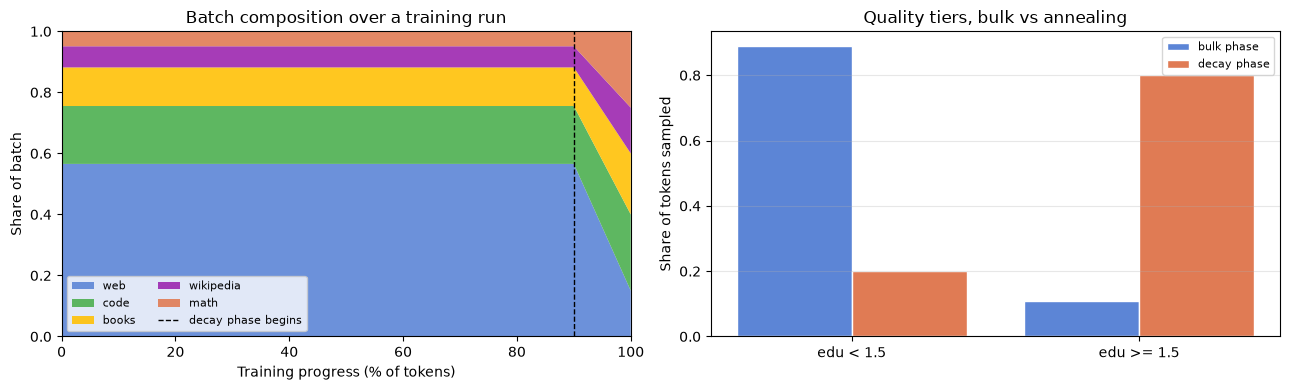

The two curves are deliberately aligned: the high-quality share rises exactly as the
learning rate falls, so the best data is seen when updates are smallest and most
permanent. At progress=0.95 the LR multiplier is 0.83 and math is 14.9% of the batch (vs 4.9% in the bulk phase).


In [ ]:
def annealed_mixture(
        progress: float, decay_start: float = 0.9, bulk_T: float = 2.0
    ) -> Dict[str, float]:
    
    """Domain weights as a function of training progress in [0, 1].

    Before `decay_start` the mixture is the fixed temperature-mixed bulk. After
    it, weights interpolate toward a high-quality target as the LR decays.
    """
    bulk = temperature_mixing(DOMAINS, bulk_T)
    target = {"web": 0.15, "code": 0.25, "books": 0.20, "wikipedia": 0.15, "math": 0.25}
    if progress < decay_start:
        return bulk
    alpha = (progress - decay_start) / (1.0 - decay_start)  # 0 -> 1 across the decay
    return {d: (1 - alpha) * bulk[d] + alpha * target[d] for d in DOMAINS}

EDU_THRESHOLD = 1.5
steps = np.linspace(0, 1, 200)
weights = {d: np.array([annealed_mixture(p)[d] for p in steps]) for d in DOMAINS}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].stackplot(steps * 100, *[weights[d] for d in DOMAINS], labels=list(DOMAINS),
                  colors=["#5c85d6", "#4CAF50", "#FFC107", "#9C27B0", "#e07b54"], alpha=0.9)
axes[0].axvline(90, color="black", ls="--", lw=1, label="decay phase begins")
axes[0].set_title("Batch composition over a training run")
axes[0].set_xlabel("Training progress (% of tokens)")
axes[0].set_ylabel("Share of batch")
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8, loc="lower left", ncol=2)

# the same idea expressed on the corpus we actually scored
scored = [d for d in SAMPLE if "edu_score" in d]
lo_q = [d for d in scored if d["edu_score"] < EDU_THRESHOLD]
hi_q = [d for d in scored if d["edu_score"] >= EDU_THRESHOLD]
bulk_share = [len(lo_q) / len(scored), len(hi_q) / len(scored)]
anneal_share = [0.2, 0.8]
x = np.arange(2)
axes[1].bar(x - 0.2, bulk_share, 0.4, label="bulk phase", color="#5c85d6", edgecolor="white")
axes[1].bar(x + 0.2, anneal_share, 0.4, label="decay phase", color="#e07b54", edgecolor="white")
axes[1].set_xticks(x, [f"edu < {EDU_THRESHOLD}", f"edu >= {EDU_THRESHOLD}"])
axes[1].set_title("Quality tiers, bulk vs annealing")
axes[1].set_ylabel("Share of tokens sampled")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

lr = np.where(steps < 0.9, 1.0, np.cos((steps - 0.9) / 0.2 * np.pi / 2) ** 2)
print(f"The two curves are deliberately aligned: the high-quality share rises exactly as the\n"
      f"learning rate falls, so the best data is seen when updates are smallest and most\n"
      f"permanent. At progress=0.95 the LR multiplier is {lr[190]:.2f} and math is "
      f"{annealed_mixture(0.95)['math']:.1%} of the batch (vs "
      f"{annealed_mixture(0.0)['math']:.1%} in the bulk phase).")